In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import kstest, norm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# **1. Линейная регрессия**

**1) Выбираем датасет ToyotaCorolla.csv**

In [18]:
df = pd.read_csv('/content/ToyotaCorolla.csv')
df = df.drop_duplicates()

**2) Первичный анализ данных (EDA) и предобработка**

First dataset strings::


,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


Columns info::
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Id                 1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax      1436 non

,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Missing values per column::
Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64


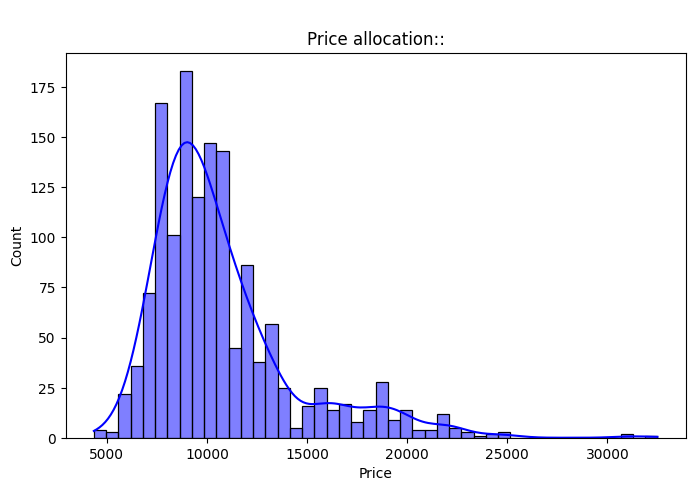

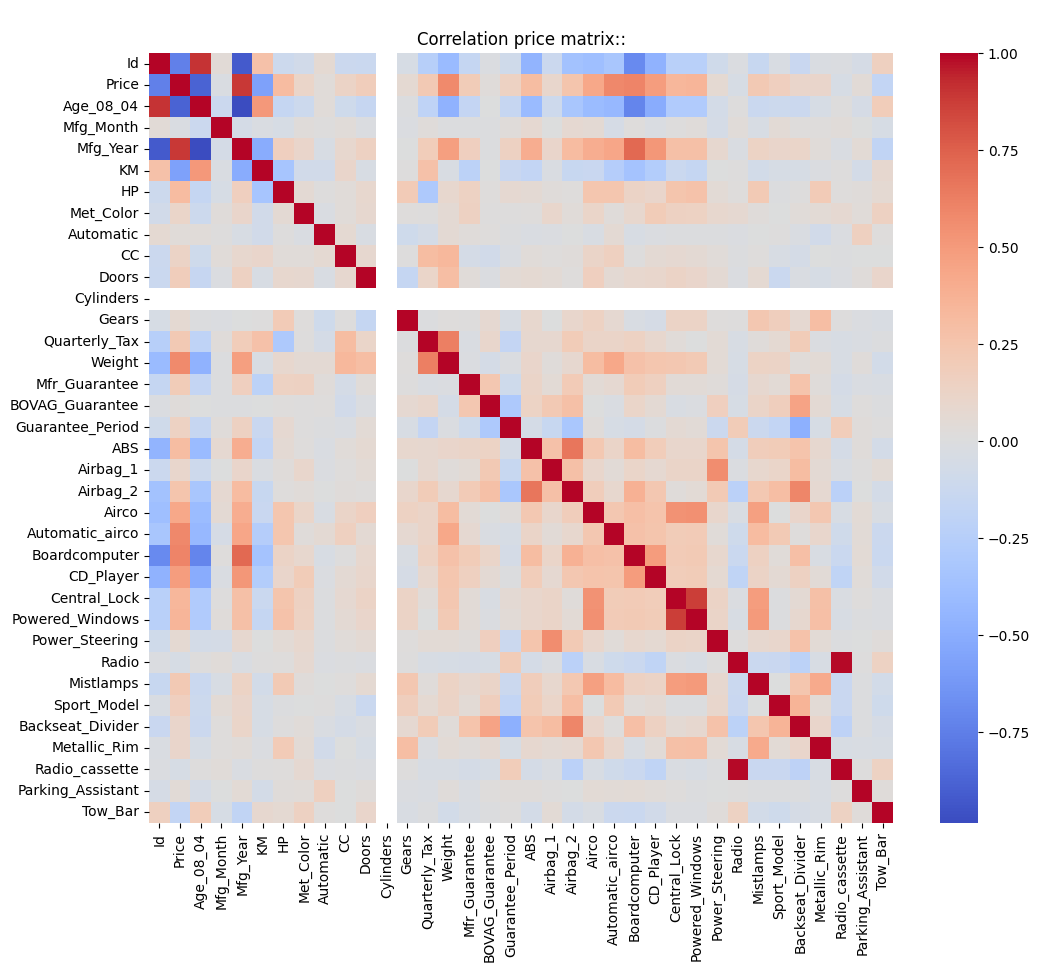

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
print("First dataset strings::")
display(df.head())
print("Columns info::")
df.info()
print("\nNumeric columns statistics::")
display(df.describe())
print("\nMissing values per column::")
print(df.isnull().sum())
df['Price'].value_counts()
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('\nPrice allocation::')
plt.show()
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title('\nCorrelation price matrix::')
plt.show()


In [20]:
# Используем StandartScaler и выводим результаты масштабирования
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('Price')
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])
print(df_scaled[num_cols].describe().loc[['mean', 'std']])

                Id     Age_08_04     Mfg_Month      Mfg_Year            KM  \
mean -7.916911e-17 -2.375073e-16  1.187537e-16  4.116794e-15  1.583382e-16   
std   1.000348e+00  1.000348e+00  1.000348e+00  1.000348e+00  1.000348e+00   

                HP     Met_Color     Automatic            CC         Doors  \
mean -3.414168e-16 -9.896138e-18 -3.958455e-17  2.474035e-16 -3.364687e-16   
std   1.000348e+00  1.000348e+00  1.000348e+00  1.000348e+00  1.000348e+00   

      ...  Powered_Windows  Power_Steering         Radio     Mistlamps  \
mean  ...     1.088575e-16   -6.927297e-17 -2.968842e-17 -3.958455e-17   
std   ...     1.000348e+00    1.000348e+00  1.000348e+00  1.000348e+00   

       Sport_Model  Backseat_Divider  Metallic_Rim  Radio_cassette  \
mean -9.896138e-17     -9.896138e-18 -9.896138e-17   -1.484421e-17   
std   1.000348e+00      1.000348e+00  1.000348e+00    1.000348e+00   

      Parking_Assistant       Tow_Bar  
mean           0.000000 -1.385459e-16  
std            1

При проведении EDA было установлено наличие в датасете признаков с разным порядком величин, при этом Fuel_Type, Model и Color имеют object значения. В качестве предообработки я удалил дубликаты строк и проверил данные на наличие пропущенных значений. Для корректной работы модели я применил StandardScaler

**3) Работа с признаками (Feature Engineering)**

In [21]:
# Удаляем колонки, не несущие важной информации
columns = ['Id', 'Model', 'Cylinders']
df = df.drop(columns=columns)
# Удаляем Mfg_Year из-за мультиколлинеарности с Age
df = df.drop(columns=['Mfg_Year'])
# One-hot encoding для колонок Fuel_type и Color
categorical_cols = ['Fuel_Type', 'Color']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
display(df.head())

,Price,Age_08_04,Mfg_Month,KM,HP,Met_Color,Automatic,CC,Doors,Gears,...,Fuel_Type_Petrol,Color_Black,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow
0,13500,23,10,46986,90,1,0,2000,3,5,...,False,False,True,False,False,False,False,False,False,False
1,13750,23,10,72937,90,1,0,2000,3,5,...,False,False,False,False,False,False,True,False,False,False
2,13950,24,9,41711,90,1,0,2000,3,5,...,False,False,True,False,False,False,False,False,False,False
3,14950,26,7,48000,90,0,0,2000,3,5,...,False,True,False,False,False,False,False,False,False,False
4,13750,30,3,38500,90,0,0,2000,3,5,...,False,True,False,False,False,False,False,False,False,False


**4) Разделение выборки**

In [22]:
y = df['Price']
X = df.drop(columns=['Price'])
# train / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

- Как именно вы разделили выборку?

Я разделил данные на train и test в отношении 80% и 20%
- Для чего это нужно? Зачем мы вообще отделяем часть данных и почему нельзя обучать и проверять модель на одном и том же наборе?

Это необходимо, чтобы не произошло переобучения и модель просто не подстроилась под train данные. Для этого мы тестируем эффективность предсказания на других test данных


**5) Обучение моделей**

In [23]:
import time
# Basic, Ridge, Lasso models
models = [
    ('Linear', LinearRegression()),
    ('Ridge', Ridge(alpha=1.0)),
    ('Lasso', Lasso(alpha=1.0))
]
results = []

for name, model in models:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    start_time = time.time()
    pipe.fit(X_train, y_train)
    end_time = time.time()
    training_time = end_time - start_time
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)
    # Metrics
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mape = mean_absolute_percentage_error(y_test, y_test_pred)

    results.append({
        'Model': name,
        'R2 Train': r2_train,
        'R2 Test': r2_test,
        'RMSE': rmse,
        'MAPE': mape,
        'Training time (sec)': training_time
    })

results_df = pd.DataFrame(results)
print(results_df)

    Model  R2 Train   R2 Test         RMSE      MAPE  Training time (sec)
0  Linear  0.977038 -0.382178  4294.427159  0.166240             0.520088
1   Ridge  0.972209  0.834818  1484.583055  0.098921             0.141374
2   Lasso  0.967829  0.874046  1296.373484  0.088101             0.945788



- Базовая линейная регрессия с полиномиальными параметрами показывается худшие результаты по точности (R2 test) и получает самую большую ошибку RMSE=4294.427159.
- Lasso показала лучший результат R2 test среди трех моделей, но оказалась самой долгой по времени выполнения
- Ridge оказалась самой быстрой моделью, а результат по R2 test сравнимый с Lasso

**6) Оценка качества и сравнение моделей**

*1. Какие метрики вы использовали для сравнения моделей? (Обоснуйте выбор: например, почему RMSE, а не MAE, или наоборот. Зачем нужен
$R^2$?).*

Я использовал RMSE, MAE и R2. RMSE показывает абсолютную ошибку а также по ней можно сделать некоторые выводы о выбросах в выборке. MAPE показывает в процентах относительную ошибку в выборке, а по R2 можно сделать вывод о переобучении модели

*2. На какой части выборки вы считали метрики?*
 Метрики считались и на train (0.8) части выборки, и на test(0.2), для проверки реального качества предсказания.

*3. Какая модель по итогу справилась лучше?*

Рекордсменом по скорости оказалась Ridge, а лучший результат качества у Lasso

*4. Насколько хорошие получились результаты?*

Ridge и Lasso получили отличные результаты на тестовой выборке

*5. Чем докажете, что ваша модель не переобучилась?*

Переобучение можно определить по значению R2 для тестовой выборки

## **2. Случайный лес**

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor

**1) Разделение выборки**

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Обязательно объясните текстом:**
* **Сделали ли вы предобработку данных для случайного леса? Отличалась ли она от предобработки данных для линейной модели? Если до, то почему?** Случайный лес не требует применения StandartScaler, так как делает предположения на основе пороговых значений, поэтому он не чувствителен к масштабу признаков
* **Как именно вы разделили выборку?** train/test 80/20
* **На сколько частей нужно делить выборку при использовании кросс-валидации?** Обычно при кросс-валидации выборку делят на 5 частей
* **Можно ли не использовать кросс-валидацию? Если да, то как делить выборку в таком случае?** Можно не использовать кросс-валидацию, если данных много, тогда можно поделить данные на train/test выборку в отношении 80/20

**2) Обучите случайный лес. Обучите одно дерево той же глубины, какую вы укажете в случайном лесе. Сравните результаты.**

In [26]:
import time


rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_start = time.perf_counter()
rf_model.fit(X_train, y_train)
rf_end = time.perf_counter()

y_rf_pred = rf_model.predict(X_test)
MSE_rf = mean_squared_error(y_test, y_rf_pred)
MAE_rf = mean_absolute_error(y_test, y_rf_pred)
r2_rf = r2_score(y_test, y_rf_pred)

print(f"Random Forest MSE = {MSE_rf:.4f}")
print(f"Random Forest MAE = {MAE_rf:.4f}")
print(f"Random Forest r2_score = {r2_rf:.4f}")

dt_clf = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)

dt_start = time.perf_counter()
dt_clf.fit(X_train, y_train)
dt_end = time.perf_counter()

y_dt_pred = dt_clf.predict(X_test)
MSE_dt = mean_squared_error(y_test, y_dt_pred)
MAE_dt = mean_absolute_error(y_test, y_dt_pred)
r2_dt = r2_score(y_test, y_dt_pred)

print(f"Decision Tree MSE = {MSE_dt:.4f}")
print(f"Decision Tree MAE = {MAE_dt:.4f}")
print(f"Decision Tree r2_score = {r2_dt:.4f}")

print(f"\nRF training: {(rf_end - rf_start)*1000:.2f} ms")
print(f"DT training: {(dt_end - dt_start)*1000:.2f} ms")

Random Forest MSE = 1085828.5224
Random Forest MAE = 794.4267
Random Forest r2_score = 0.9186
Decision Tree MSE = 1446784.6738
Decision Tree MAE = 900.4206
Decision Tree r2_score = 0.8916

RF training: 598.68 ms
DT training: 9.10 ms


**Вопросы для анализа:**
* **Сравнение скорости:** сравните, какая модель обучалась быстрее. - Decision tree обучалось быстрее, ведь Random Forest является ансамблем и требует обучения большого количества деревьев
* **Можно ли добиться одинаковой или близкой к одинаковой скорости?** - При уменьшении количества деревьев в Random Forest можно сократить временной разрыв, однако его обучение все еще будет занимать больше времени
* **Сравнение качества:** сравните результаты одного дерева и случайного леса. Результаты показывают, что Random Forest лучше по всем метрикам(MSE, MAE, R2), чем Decision Tree за счет усреднения ошибок отдельных деревьев и снижения дисперсии в ансамбле

**3) Оценка качества и сравнение моделей** Сравните свои результаты с теми, которые вы получили от линейной регрессии.


In [27]:
dt_models = [
    ('Decision Tree', dt_clf),
    ('Random Forest', rf_model)
]

for name, model in dt_models:
    pipe = Pipeline([
        ('model', model)
    ])
    start_time = time.time()
    pipe.fit(X_train, y_train)
    end_time = time.time()
    training_time = end_time - start_time
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)
    # Metrics
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mape = mean_absolute_percentage_error(y_test, y_test_pred)

    results.append({
        'Model': name,
        'R2 Train': r2_train,
        'R2 Test': r2_test,
        'RMSE': rmse,
        'MAPE': mape,
        'Training time (sec)': training_time
    })
print(pd.DataFrame(results))

           Model  R2 Train   R2 Test         RMSE      MAPE  \
0         Linear  0.977038 -0.382178  4294.427159  0.166240   
1          Ridge  0.972209  0.834818  1484.583055  0.098921   
2          Lasso  0.967829  0.874046  1296.373484  0.088101   
3  Decision Tree  0.917980  0.891568  1202.823625  0.095109   
4  Random Forest  0.932129  0.918621  1042.030960  0.083963   

   Training time (sec)  
0             0.520088  
1             0.141374  
2             0.945788  
3             0.015662  
4             0.574502  


# **Итоги**


**Random Forest**: показывает наименьшее переобучение (0.9321 на train и	0.9186 на test) и лучшее качество r2_test - 0.918621

**Decision Tree**: самая быстрая модель (удобно использовать, когда важна скорость обучения), на втором месте по качеству r2_test - 0.891568

**Linear**: разрыв r2_train и r2_test в 1.3592 указывает на катастрофическое переобучение

**Lasso**: самая медленная модель среди линейных - скорость обучения составила 0.945788 sec, однако демонстрирует лучшую среди линейных моделей способность к обобщению (0.9678 на train и 0.8740 на test)

**Ridge**: второе место по скорости обучения среди всех моделей - 0.141374 sec, разрыв между train/test составляет 0.1374, что указывает на заметное переобучение